## More stats to validate the results

In [ ]:
# divided
# /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/divided/176x88x48/variable_voxel_distance/mean_two_landmarks/straight_model/learning_rate/0.0001/19Nov2025-10:01:33-trainID-2

In [1]:
# the data i needed, final results
## cropped size (63, 50, 61)
## fc - org - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/09Jul2024-12:12:48-trainID-33.3
## fc - retrain - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3
## final_Y_test_pred.npy, Y_test_true.npy, res_test.npy, best_val_Y_CTPre14_pred.npy, Y_CTPre14_true.npy, res_CTPre14.npy
## dsnt - "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/u_net_dsnt/turner_results/random_grid_0/14Aug2024-04:36:02-trainID-13.1"
import os
import numpy as np

ret_dir = "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/19Nov2025-13:17:24-trainID-33.3"
y_test_true = np.load(os.path.join(ret_dir, "Y_test_true.npy"))
y_test_pred = np.load(os.path.join(ret_dir, "final_Y_test_pred.npy"))
res_test = np.load(os.path.join(ret_dir, "res_test.npy"))

y_CTPre14_true = np.load(os.path.join(ret_dir, "Y_CTPre14_true.npy"))
y_CTPre14_pred = np.load(os.path.join(ret_dir, "best_val_Y_CTPre14_pred.npy"))
res_CTPre14 = np.load(os.path.join(ret_dir, "res_CTPre14.npy"))

In [2]:
# find the maximum error in test set
# find the maximum error in test set (per-landmark, record patient/side/landmark)
patient_names_14 = ['CD', 'DN', 'GS', 'HME', 'LY', 'MG', 'MM', 'NJ', 'RM', 'SL', 'TA', 'TG', 'VPR', 'YJ']

t = np.asarray(y_CTPre14_true, float)   # (28,2,3)
p = np.asarray(y_CTPre14_pred, float)

if t.shape != p.shape:
    raise ValueError(f"y_CTPre14_true/pred shape mismatch: {t.shape} vs {p.shape}")
if t.ndim != 3 or t.shape[1] != 2 or t.shape[2] != 3:
    raise ValueError(f"Unexpected shape for y_CTPre14_true/pred: {t.shape}")

n_results = t.shape[0]
n_patients = n_results // 2
if n_results != 2 * len(patient_names_14):
    raise ValueError(f"Number of results ({n_results}) != 2 * len(patient_names_14) ({2*len(patient_names_14)})")

# prepare per-result voxel scaling (squeeze shapes like (28,1,3) -> (28,3))
res_arr = np.asarray(res_CTPre14)
res_flat = np.squeeze(res_arr)
if res_flat.ndim == 1 and res_flat.size == 3:
    # same scaling for all results
    res_flat = np.tile(res_flat, (n_results, 1))
elif res_flat.shape[0] != n_results or res_flat.shape[1] != 3:
    # attempt reshape if necessary
    try:
        res_flat = res_flat.reshape(n_results, 3)
    except Exception:
        # fallback to uniform 0.15
        res_flat = np.full((n_results, 3), 0.15, dtype=float)

# build per-landmark entries and per-patient dict
entries = []   # list of tuples (err_mm, patient, side, landmark, result_idx, landmark_idx)
patient_errors = {name: {} for name in patient_names_14}

for r in range(n_results):
    patient_idx = r // 2
    patient = patient_names_14[patient_idx]
    side = 'L' if (r % 2) == 0 else 'R'
    for l_idx, landmark_name in enumerate(['ant', 'post']):
        diff_vox = t[r, l_idx] - p[r, l_idx]           # (3,)
        diff_mm = diff_vox * res_flat[r]              # apply per-result voxel spacing
        err_mm = float(np.linalg.norm(diff_mm))
        entries.append((err_mm, patient, side, landmark_name, r, l_idx))
        patient_errors[patient][f"{side}_{landmark_name}"] = err_mm

# sort entries by error descending
entries_sorted = sorted(entries, key=lambda x: x[0], reverse=True)

# also produce a patient-sorted dict by max error (descending)
patient_max = {name: max(patient_errors[name].values()) for name in patient_names_14}
patient_sorted_by_max = dict(sorted(patient_errors.items(), key=lambda kv: float(max(kv[1].values())), reverse=True))

# save results
out_landmarks = os.path.join(ret_dir, "CTPre14_landmark_errors_sorted.npy")
out_patients = os.path.join(ret_dir, "CTPre14_patient_errors_by_landmark.npy")
np.save(out_landmarks, entries_sorted, allow_pickle=True)
np.save(out_patients, patient_sorted_by_max, allow_pickle=True)

# print brief summary (top 10 landmarks and per-patient max)
print("Top landmarks by error (mm):")
for e in entries_sorted[:10]:
    print(f"err={e[0]:.4f} mm  patient={e[1]}  side={e[2]}  landmark={e[3]}  result_idx={e[4]} landmark_idx={e[5]}")

print("\nPer-patient errors (sorted by patient max error):")
for name, errs in patient_sorted_by_max.items():
    vals = [f"{k}:{v:.4f}" for k, v in errs.items()]
    print(f"{name}: " + ", ".join(vals) + f"   max={max(errs.values()):.4f}")

print("Saved:", out_landmarks, out_patients)

Top landmarks by error (mm):
err=1.2644 mm  patient=VPR  side=L  landmark=post  result_idx=24 landmark_idx=1
err=0.8936 mm  patient=VPR  side=L  landmark=ant  result_idx=24 landmark_idx=0
err=0.7905 mm  patient=TG  side=L  landmark=post  result_idx=22 landmark_idx=1
err=0.7610 mm  patient=VPR  side=R  landmark=post  result_idx=25 landmark_idx=1
err=0.7278 mm  patient=VPR  side=R  landmark=ant  result_idx=25 landmark_idx=0
err=0.6835 mm  patient=TA  side=L  landmark=post  result_idx=20 landmark_idx=1
err=0.6519 mm  patient=DN  side=R  landmark=post  result_idx=3 landmark_idx=1
err=0.6018 mm  patient=HME  side=L  landmark=post  result_idx=6 landmark_idx=1
err=0.5722 mm  patient=RM  side=L  landmark=post  result_idx=16 landmark_idx=1
err=0.5678 mm  patient=MM  side=L  landmark=ant  result_idx=12 landmark_idx=0

Per-patient errors (sorted by patient max error):
VPR: L_ant:0.8936, L_post:1.2644, R_ant:0.7278, R_post:0.7610   max=1.2644
TG: L_ant:0.2479, L_post:0.7905, R_ant:0.1794, R_post:0

In [ ]:
# based on the results, may need to check specific patients/landmarks further
# VPR - all
# TG  - LLSCC Post
# TA  - LLSCC Post
# DN  - RLSCC Post
# HME - LLSCC Post 

In [4]:
arr_entities = np.asarray(entries_sorted, dtype=object)
mean_error = np.mean(arr_entities[:,0].astype(float))
print(f"\nMean error across all landmarks: {mean_error:.4f} mm")


Mean error across all landmarks: 0.3751 mm


### Bland–Altman plot
A Bland–Altman plot (also called a difference plot) is a method to compare two measurement techniques or two sets of measurements of the same variable — for example, comparing a new medical imaging algorithm’s output to a gold-standard method.

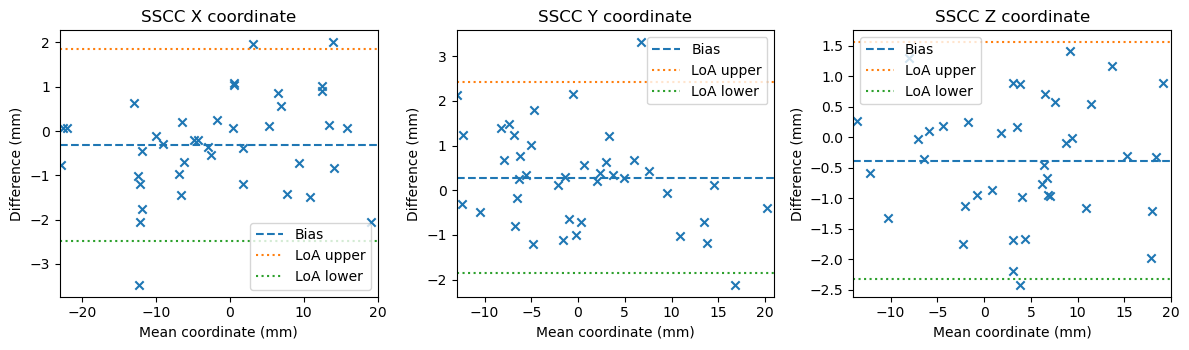

In [2]:
# the stats functions
import numpy as np
import matplotlib.pyplot as plt

def bland_altman_basic(ob1, ob2, ax=None, title="Bland–Altman", xlab="Mean", ylab="Diff"):
    """
    Basic Bland–Altman for 1D paired data.
    Draws bias and limits of agreement (±1.96*SD). Returns (fig, ax).
    """
    ob1 = np.asarray(ob1, float).ravel()
    ob2 = np.asarray(ob2, float).ravel()
    if ob1.size != ob2.size or ob1.size < 3:
        raise ValueError("Need >=3 paired observations with equal length.")

    mean_ob = (ob1 + ob2) / 2.0
    diff_ob = ob1 - ob2
    bias = np.mean(diff_ob)
    sd   = np.std(diff_ob, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    ax.scatter(mean_ob, diff_ob, marker='x')          # keep default colors
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    ax.plot([x_min, x_max], [bias, bias], linestyle='--', label="Bias")
    ax.plot([x_min, x_max], [loa_upper, loa_upper], linestyle=':', label="LoA upper")
    ax.plot([x_min, x_max], [loa_lower, loa_lower], linestyle=':', label="LoA lower")
    ax.set_xlim(x_min, x_max)
    y_min = min(diff_ob.min(), loa_lower)
    y_max = max(diff_ob.max(), loa_upper)
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    return fig, ax


def bland_altman_3d_per_axis(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Basic per-axis Bland–Altman for 3D landmarks.
    pts*_mm: arrays of shape (N, 3) in millimetres, matched point-wise.
    Returns (fig, axes).
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    labels = ["X", "Y", "Z"]

    for i, lab in enumerate(labels):
        bland_altman_basic(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlab="Mean coordinate (mm)",
            ylab="Difference (mm)",
        )
    fig.tight_layout()
    return fig, axes

# ---- tiny example ----
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    # fake 3D points (N,3)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="SSCC")
    plt.show()


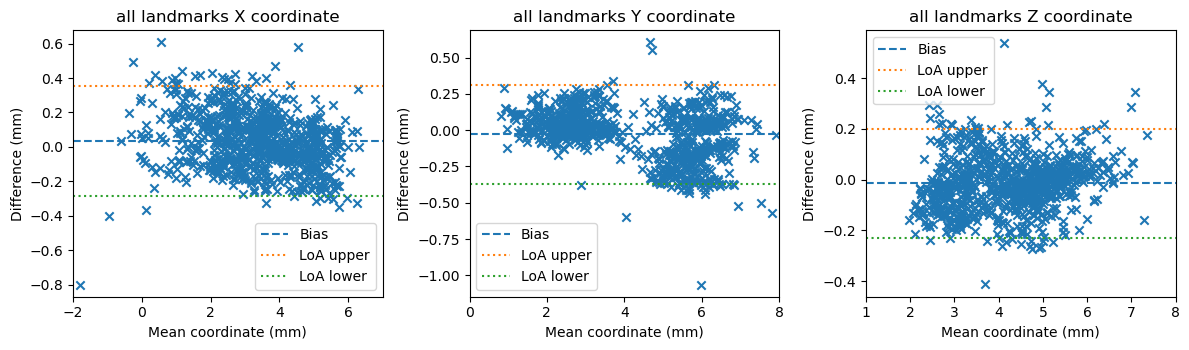

In [3]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="all landmarks")
    plt.show()

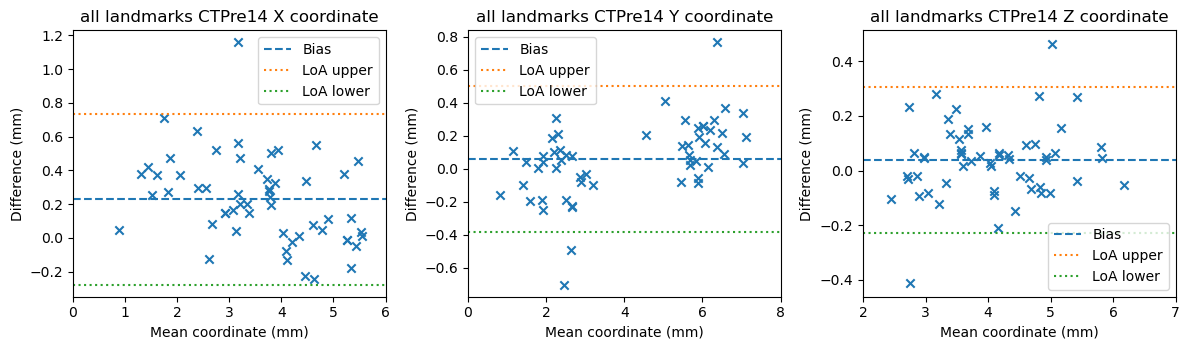

In [4]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="all landmarks CTPre14")
    plt.show()

### Confidence intervals

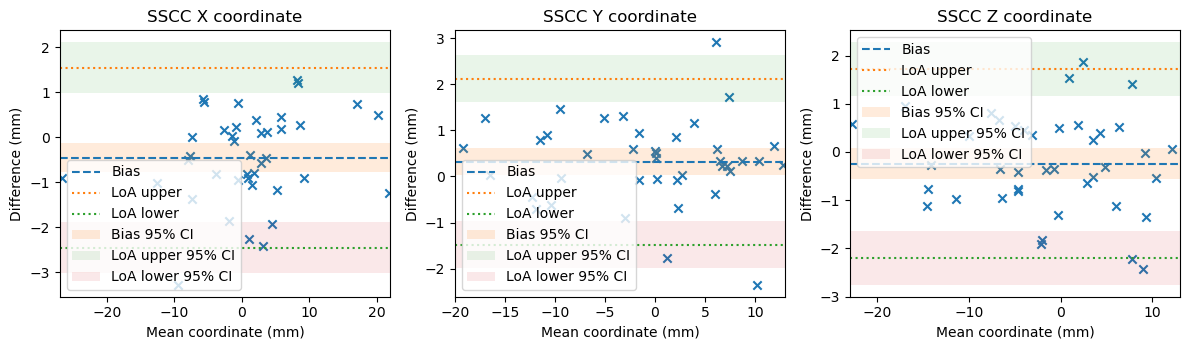

In [ ]:
# the stats function
import numpy as np
import matplotlib.pyplot as plt

def _tcrit(df: int, alpha: float = 0.05) -> float:
    """Two-sided t critical value; falls back to ~1.96 if SciPy not installed."""
    try:
        from scipy.stats import t
        return float(t.ppf(1 - alpha/2, df))
    except Exception:
        return 1.96  # Normal approx

def bland_altman_with_ci(
    ob1,
    ob2,
    ax=None,
    title="Bland–Altman (with 95% CIs)",
    xlabel="Mean of methods",
    ylabel="Difference (ob1 − ob2)",
    loa_z: float = 1.96,         # 95% LoA
    alpha: float = 0.05,         # 95% CI bands
):
    """
    Basic Bland–Altman plot with shaded 95% CIs for bias and LoA.

    Parameters
    ----------
    ob1, ob2 : array-like (1D, same length)
        Paired measurements from two methods.
    ax : matplotlib Axes, optional
    loa_z : float
        Z multiplier for LoA (1.96 → ~95%).
    alpha : float
        CI level for shaded bands (0.05 → 95% CI).

    Returns
    -------
    fig, ax, stats : (Figure, Axes, dict)
        stats contains bias, sd, loa_lower/upper and CI bounds.
    """
    x = np.asarray(ob1, float).ravel()
    y = np.asarray(ob2, float).ravel()
    if x.size != y.size or x.size < 3:
        raise ValueError("Need ≥3 paired observations of equal length.")
    n = x.size
    df = n - 1

    mean_ob = (x + y) / 2.0
    diff_ob = x - y

    bias = float(np.mean(diff_ob))
    sd   = float(np.std(diff_ob, ddof=1))
    loa_lower = bias - loa_z * sd
    loa_upper = bias + loa_z * sd

    # CIs (Bland & Altman 1999)
    tcrit = _tcrit(df, alpha=alpha)
    se_bias = sd / np.sqrt(n)
    se_loa = sd * np.sqrt(1.0/n + (loa_z**2) / (2*(n-1)))

    bias_ci = (bias - tcrit*se_bias, bias + tcrit*se_bias)
    loa_lower_ci = (loa_lower - tcrit*se_loa, loa_lower + tcrit*se_loa)
    loa_upper_ci = (loa_upper - tcrit*se_loa, loa_upper + tcrit*se_loa)

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    # Scatter
    ax.scatter(mean_ob, diff_ob, marker="x")  # (no explicit colors)

    # Horizontal lines
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    xx = np.array([x_min, x_max], float)
    ax.plot(xx, [bias, bias], linestyle="--", label="Bias")
    ax.plot(xx, [loa_upper, loa_upper], linestyle=":", label="LoA upper")
    ax.plot(xx, [loa_lower, loa_lower], linestyle=":", label="LoA lower")

    # Shaded CI bands
    ax.fill_between(xx, bias_ci[0], bias_ci[1], alpha=0.15, label="Bias 95% CI")
    ax.fill_between(xx, loa_upper_ci[0], loa_upper_ci[1], alpha=0.10, label="LoA upper 95% CI")
    ax.fill_between(xx, loa_lower_ci[0], loa_lower_ci[1], alpha=0.10, label="LoA lower 95% CI")

    # Axes, labels
    y_min = min(diff_ob.min(), loa_lower_ci[0])
    y_max = max(diff_ob.max(), loa_upper_ci[1])
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    stats = dict(
        n=n, bias=bias, sd=sd,
        loa_lower=loa_lower, loa_upper=loa_upper,
        bias_ci=bias_ci, loa_lower_ci=loa_lower_ci, loa_upper_ci=loa_upper_ci,
    )
    return fig, ax, stats


# ---------- Optional: per-axis 3D helper (simple) ----------

def bland_altman_3d_per_axis_with_ci(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Per-axis BA with 95% CI bands for 3D landmarks.
    pts*_mm: arrays (N, 3) in millimetres.
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for i, lab in enumerate(["X", "Y", "Z"]):
        bland_altman_with_ci(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlabel="Mean coordinate (mm)",
            ylabel="Difference (mm)"
        )
    fig.tight_layout()
    return fig, axes


# ---- tiny demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="LSCC")
    plt.show()


{'n': 40, 'bias': 0.1887986110433551, 'sd': 1.0181354524069817, 'loa_lower': -1.806746875674329, 'loa_upper': 2.184344097761039, 'bias_ci': (np.float64(-0.13681690350976405), np.float64(0.5144141255964743)), 'loa_lower_ci': (np.float64(-2.3679073369122836), np.float64(-1.2455864144363744)), 'loa_upper_ci': (np.float64(1.6231836365230845), np.float64(2.7455045589989937))}


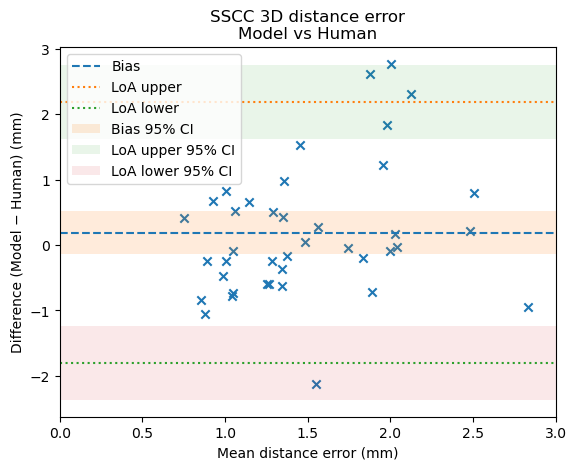

In [7]:
# add per distance Bland–Altman plots with CIs
def bland_altman_3d_distance_with_ci(
    ref_pts_mm,
    pts1_mm,
    pts2_mm,
    roi_name: str = "ROI",
    method1_label: str = "Method 1",
    method2_label: str = "Method 2",
):
    """
    Bland–Altman on 3D *distance errors* for landmarks.

    Parameters
    ----------
    ref_pts_mm : (N, 3)
        Reference landmarks (e.g. ground truth) in mm.
    pts1_mm : (N, 3)
        Landmarks from method 1 (e.g. model predictions) in mm.
    pts2_mm : (N, 3)
        Landmarks from method 2 (e.g. human annotations, baseline model) in mm.

    Returns
    -------
    fig, ax, stats
        BA figure, axis and stats dict from bland_altman_with_ci.
    """
    ref_pts_mm = np.asarray(ref_pts_mm, float)
    pts1_mm    = np.asarray(pts1_mm, float)
    pts2_mm    = np.asarray(pts2_mm, float)

    if ref_pts_mm.shape != pts1_mm.shape or ref_pts_mm.shape != pts2_mm.shape:
        raise ValueError("ref_pts_mm, pts1_mm, pts2_mm must all be (N,3) with same shape.")

    if ref_pts_mm.ndim != 2 or ref_pts_mm.shape[1] != 3:
        raise ValueError("Expected (N,3) arrays for landmarks in mm.")

    # 3D Euclidean distance errors to the reference (per landmark)
    err1 = np.linalg.norm(pts1_mm - ref_pts_mm, axis=1)
    err2 = np.linalg.norm(pts2_mm - ref_pts_mm, axis=1)

    title = f"{roi_name} 3D distance error\n{method1_label} vs {method2_label}"
    xlabel = "Mean distance error (mm)"
    ylabel = f"Difference ({method1_label} − {method2_label}) (mm)"

    fig, ax, stats = bland_altman_with_ci(
        err1,
        err2,
        ax=None,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
    )
    return fig, ax, stats

# ---- tiny demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    n = 40

    # Fake ground truth landmarks
    ref = rng.normal(0, 10, size=(n, 3))

    # Method 1: slightly biased + noise
    pts1 = ref + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(n, 3))

    # Method 2: different bias + noise
    pts2 = ref + np.array([0.1, 0.0, 0.3]) + rng.normal(0, 1.0, size=(n, 3))

    fig, ax, stats = bland_altman_3d_distance_with_ci(
        ref, pts1, pts2,
        roi_name="SSCC",
        method1_label="Model",
        method2_label="Human"
    )
    print(stats)
    plt.show()


{'n': 28, 'bias': 0.2873589970527867, 'sd': 0.19102540238062146, 'loa_lower': -0.08705079161323132, 'loa_upper': 0.6617687857188048, 'bias_ci': (np.float64(0.21328707873069547), np.float64(0.361430915374878)), 'loa_lower_ci': (np.float64(-0.21517467277639246), np.float64(0.04107308954992983)), 'loa_upper_ci': (np.float64(0.5336449045556437), np.float64(0.7898926668819659))}


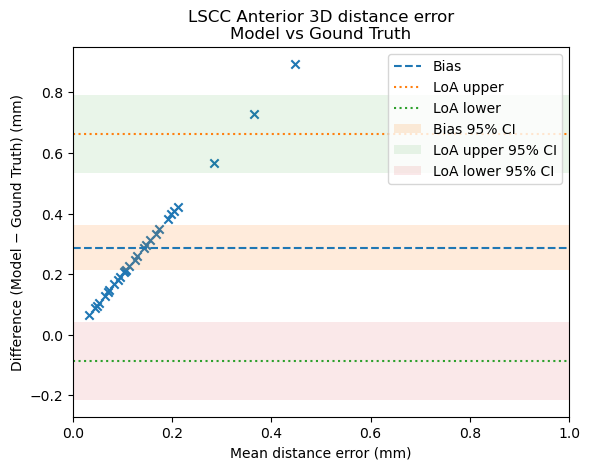

In [9]:
if __name__ == "__main__":
    # ground truth landmarks
    ref_ant = y_CTPre14_true[:, 0, :] * 0.15
    ref_pos = y_CTPre14_true[:, 1, :] * 0.15

    # Method 1: model predictions
    model_ant = y_CTPre14_pred[:, 0, :] * 0.15
    model_pos = y_CTPre14_pred[:, 1, :] * 0.15

    # Method 2: just the reference (perfect)

    fig, ax, stats = bland_altman_3d_distance_with_ci(
        ref_ant, model_ant, ref_ant,
        roi_name="LSCC Anterior",
        method1_label="Model",
        method2_label="Gound Truth"
    )
    print(stats)
    plt.show()


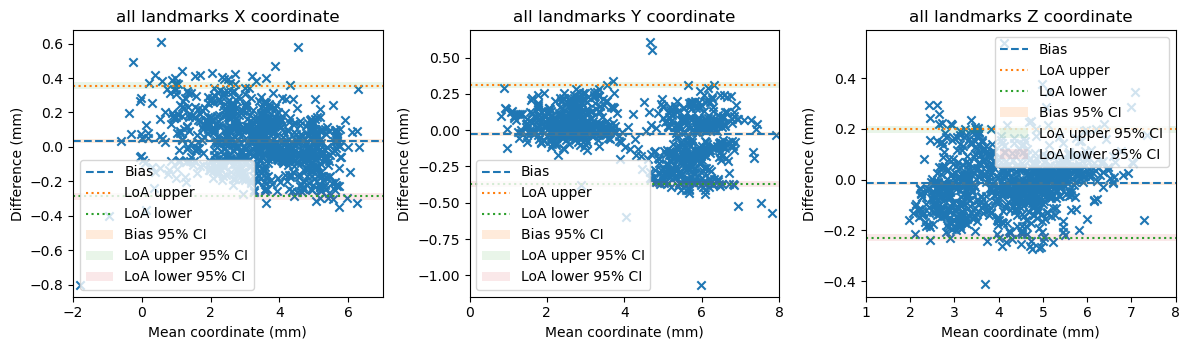

In [6]:
if __name__ == "__main__":
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="all landmarks")
    plt.show()

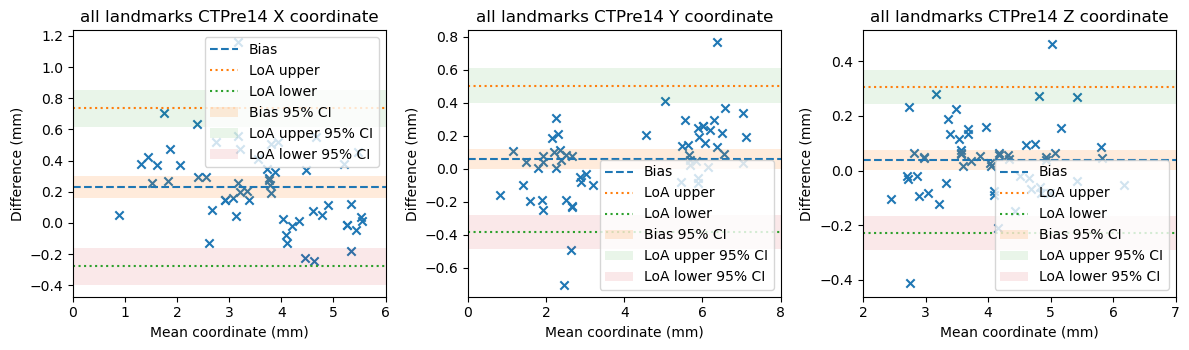

In [7]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_CTPre14_true.reshape(-1, 3) * 0.15
    p2 = y_CTPre14_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis_with_ci(p1, p2, roi_name="all landmarks CTPre14")
    plt.show()  

## TRE (Target Registration Error)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [7]:
def compute_tre(expert_coords: np.ndarray,
                model_coords: np.ndarray) -> pd.Series:
    """
    Compute TRE (Euclidean distance) between model and expert landmarks.

    Parameters
    ----------
    expert_coords : (N, 3) array
    model_coords  : (N, 3) array

    Returns
    -------
    summary : pandas.Series
        Contains per-point TRE as well as summary statistics.
    """
    expert_coords = np.asarray(expert_coords)
    model_coords  = np.asarray(model_coords)
    assert expert_coords.shape == model_coords.shape
    assert expert_coords.shape[1] == 3, "Expect shape (N, 3) for xyz"

    # per-case TRE (Euclidean distance)
    tre = np.linalg.norm(model_coords - expert_coords, axis=1)  # shape (N,)

    summary = pd.Series({
        "N": len(tre),
        "mean_TRE_mm": tre.mean(),
        "std_TRE_mm": tre.std(ddof=1),
        "median_TRE_mm": np.median(tre),
        "p95_TRE_mm": np.percentile(tre, 95),
        "max_TRE_mm": tre.max(),
    })

    return tre, summary

In [ ]:
expert_coords_all = y_CTPre14_true.reshape(-1, 3) * 0.15
model_coords_all = y_CTPre14_pred.reshape(-1, 3) * 0.15

In [15]:
tre, tre_summary = compute_tre(expert_coords_all, model_coords_all)
print(tre_summary)

N                56.000000
mean_TRE_mm       0.375112
std_TRE_mm        0.227333
median_TRE_mm     0.322808
p95_TRE_mm        0.768398
max_TRE_mm        1.264364
dtype: float64


## Bland–Altman Analysis (per axis)

In [16]:
def bland_altman_stats(expert: np.ndarray,
                       model: np.ndarray) -> dict:
    """
    Compute Bland–Altman statistics between expert and model for 1D data.

    Parameters
    ----------
    expert : (N,) array
    model  : (N,) array

    Returns
    -------
    stats : dict
        mean_diff, loa_lower, loa_upper, sd_diff
    """
    expert = np.asarray(expert)
    model  = np.asarray(model)
    diff   = model - expert
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    loa_lower = mean_diff - 1.96 * sd_diff
    loa_upper = mean_diff + 1.96 * sd_diff

    return {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
    }


def bland_altman_plot(expert: np.ndarray,
                      model: np.ndarray,
                      axis_name: str = "X"):
    """
    Make a Bland–Altman plot for one coordinate axis.
    """
    expert = np.asarray(expert)
    model  = np.asarray(model)
    mean_vals = (expert + model) / 2.0
    diff      = model - expert

    stats_ba = bland_altman_stats(expert, model)

    plt.figure()
    plt.scatter(mean_vals, diff, alpha=0.7)
    plt.axhline(stats_ba["mean_diff"], linestyle='-')
    plt.axhline(stats_ba["loa_lower"], linestyle='--')
    plt.axhline(stats_ba["loa_upper"], linestyle='--')
    plt.xlabel(f"Mean of Expert and Model ({axis_name} coord, mm)")
    plt.ylabel(f"Difference (Model - Expert) ({axis_name}, mm)")
    plt.title(f"Bland–Altman Plot ({axis_name}-axis)")
    plt.tight_layout()
    plt.show()

    return stats_ba


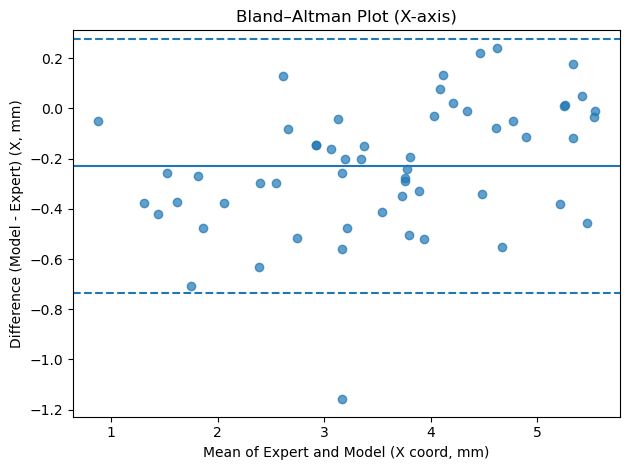

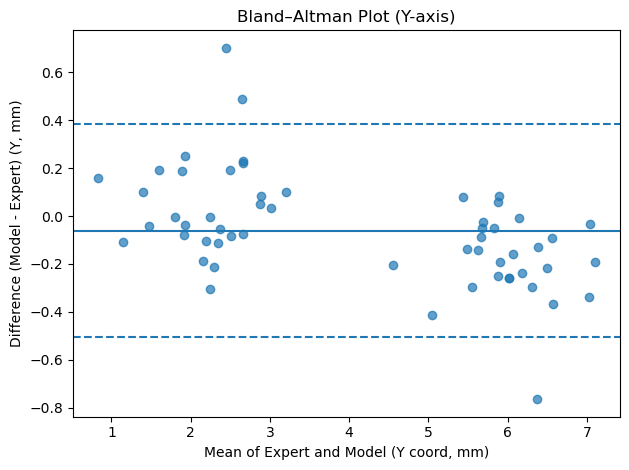

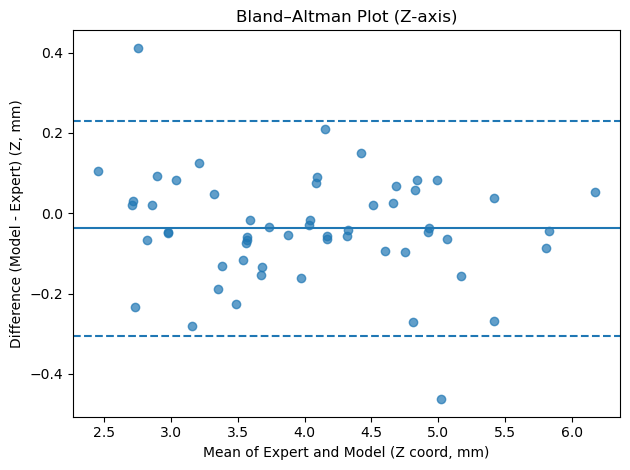

Bland–Altman X: {'mean_diff': np.float32(-0.22930257), 'sd_diff': np.float32(0.2582801), 'loa_lower': np.float32(-0.73553157), 'loa_upper': np.float32(0.2769264)}
Bland–Altman Y: {'mean_diff': np.float32(-0.060328186), 'sd_diff': np.float32(0.22582264), 'loa_lower': np.float32(-0.50294054), 'loa_upper': np.float32(0.3822842)}
Bland–Altman Z: {'mean_diff': np.float32(-0.03770759), 'sd_diff': np.float32(0.13621445), 'loa_lower': np.float32(-0.30468792), 'loa_upper': np.float32(0.22927272)}


In [17]:
x_exp, y_exp, z_exp = expert_coords_all[:,0], expert_coords_all[:,1], expert_coords_all[:,2]
x_mod, y_mod, z_mod = model_coords_all[:,0], model_coords_all[:,1], model_coords_all[:,2]

ba_x = bland_altman_plot(x_exp, x_mod, axis_name="X")
ba_y = bland_altman_plot(y_exp, y_mod, axis_name="Y")
ba_z = bland_altman_plot(z_exp, z_mod, axis_name="Z")

print("Bland–Altman X:", ba_x)
print("Bland–Altman Y:", ba_y)
print("Bland–Altman Z:", ba_z)


## TOST Equivalence Test on Mean TRE

In [20]:
def tost_equivalence_onesample(x: np.ndarray,
                               delta: float,
                               alpha: float = 0.05):
    """
    One-sample TOST for equivalence of mean(x) to 0 within margin [-delta, +delta].

    Parameters
    ----------
    x : (N,) array
        Sample values, e.g. TRE in mm.
    delta : float
        Equivalence margin in same units (e.g. 0.5 mm).
    alpha : float
        Significance level.

    Returns
    -------
    results : dict
        Contains t1, p1, t2, p2, p_TOST, mean, ci_low, ci_high, equivalent (bool)
    """
    x = np.asarray(x)
    n  = len(x)
    mean_x = x.mean()
    sd_x   = x.std(ddof=1)
    se_x   = sd_x / np.sqrt(n)
    df     = n - 1

    # Test 1: H0: μ ≤ -δ  vs  H1: μ > -δ
    t1 = (mean_x - (-delta)) / se_x
    p1 = 1 - stats.t.cdf(t1, df=df)  # one-sided

    # Test 2: H0: μ ≥ +δ  vs  H1: μ < +δ
    t2 = (mean_x - delta) / se_x
    p2 = stats.t.cdf(t2, df=df)      # one-sided

    # TOST p-value is max of the two one-sided p-values
    p_tost = max(p1, p2)

    # 100*(1-2α)% CI for mean
    ci_low, ci_high = stats.t.interval(
        confidence=1 - 2*alpha,
        df=df,
        loc=mean_x,
        scale=se_x
    )

    equivalent = p_tost < alpha

    return {
        "mean": mean_x,
        "sd": sd_x,
        "n": n,
        "delta": delta,
        "alpha": alpha,
        "t1": t1, "p1": p1,
        "t2": t2, "p2": p2,
        "p_TOST": p_tost,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "equivalent": equivalent,
    }


In [21]:
# Suppose 0.5 mm is your clinical equivalence margin
delta = 0.5
tost_res = tost_equivalence_onesample(tre, delta=delta, alpha=0.05)

print(pd.Series(tost_res))


mean           0.375112
sd             0.227333
n                    56
delta               0.5
alpha              0.05
t1            28.806828
p1                  0.0
t2            -4.111034
p2             0.000066
p_TOST         0.000066
ci_low         0.324288
ci_high        0.425937
equivalent         True
dtype: object


## % Within Clinical Tolerance

In [23]:
def percent_within_threshold(tre: np.ndarray, threshold: float) -> float:
    """
    Percentage of cases with TRE <= threshold.
    """
    tre = np.asarray(tre)
    return 100.0 * np.mean(tre <= threshold)


In [38]:
print("Percent TRE <= 0.6 mm:", percent_within_threshold(tre, 0.5), "%")
print("Percent TRE <= 1.0 mm:", percent_within_threshold(tre, 1.0), "%")


Percent TRE <= 0.6 mm: 75.0 %
Percent TRE <= 1.0 mm: 98.21428571428571 %


In [32]:
def evaluate_model_vs_expert(expert_coords, model_coords,
                             clinical_delta=0.5):
    # 1) TRE
    tre, tre_summary = compute_tre(expert_coords, model_coords)
    print("TRE summary:")
    print(tre_summary, "\n")

    # 2) % within clinically acceptable threshold
    pct_05 = percent_within_threshold(tre, clinical_delta)
    print(f"% of cases with TRE <= {clinical_delta} mm:", pct_05, "%\n")

    # 3) TOST on mean TRE
    tost_res = tost_equivalence_onesample(tre, delta=clinical_delta, alpha=0.05)
    print("TOST result:")
    print(pd.Series(tost_res), "\n")

    # 4) Bland–Altman for X, Y, Z
    x_exp, y_exp, z_exp = expert_coords[:,0], expert_coords[:,1], expert_coords[:,2]
    x_mod, y_mod, z_mod = model_coords[:,0], model_coords[:,1], model_coords[:,2]

    print("Bland–Altman X:")
    print(bland_altman_plot(x_exp, x_mod, axis_name="X"), "\n")

    print("Bland–Altman Y:")
    print(bland_altman_plot(y_exp, y_mod, axis_name="Y"), "\n")

    print("Bland–Altman Z:")
    print(bland_altman_plot(z_exp, z_mod, axis_name="Z"), "\n")

    return tre, tre_summary, tost_res

# Example call (assuming you already have expert_coords, model_coords as (N, 3))
# tre, tre_summary, tost_res = evaluate_model_vs_expert(expert_coords, model_coords, clinical_delta=0.5)


TRE summary:
N                56.000000
mean_TRE_mm       0.375112
std_TRE_mm        0.227333
median_TRE_mm     0.322808
p95_TRE_mm        0.768398
max_TRE_mm        1.264364
dtype: float64 

% of cases with TRE <= 0.6 mm: 85.71428571428571 %

TOST result:
mean           0.375112
sd             0.227333
n                    56
delta               0.6
alpha              0.05
t1            32.098615
p1                  0.0
t2            -7.402821
p2                  0.0
p_TOST              0.0
ci_low         0.324288
ci_high        0.425937
equivalent         True
dtype: object 

Bland–Altman X:


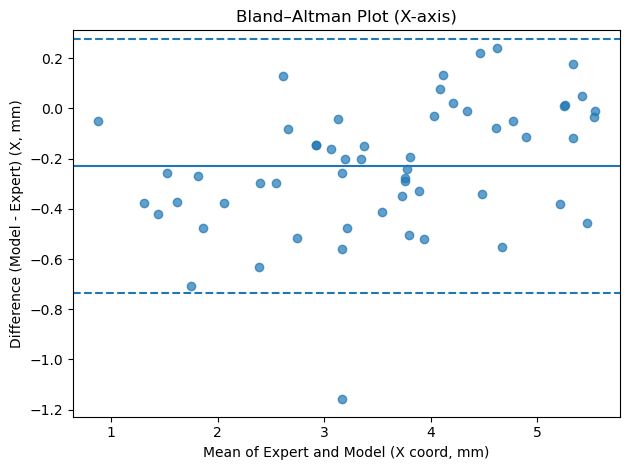

{'mean_diff': np.float32(-0.22930257), 'sd_diff': np.float32(0.2582801), 'loa_lower': np.float32(-0.73553157), 'loa_upper': np.float32(0.2769264)} 

Bland–Altman Y:


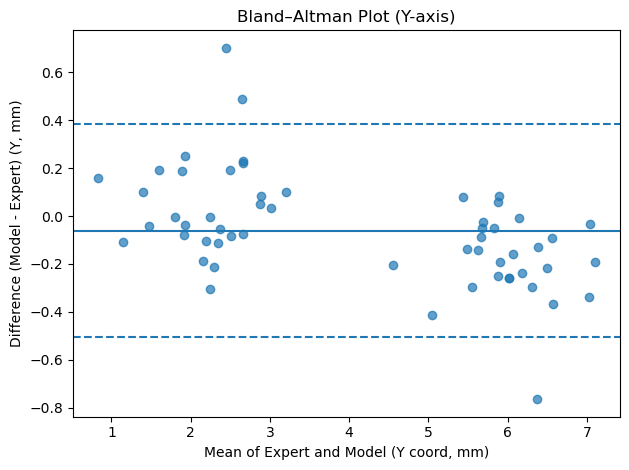

{'mean_diff': np.float32(-0.060328186), 'sd_diff': np.float32(0.22582264), 'loa_lower': np.float32(-0.50294054), 'loa_upper': np.float32(0.3822842)} 

Bland–Altman Z:


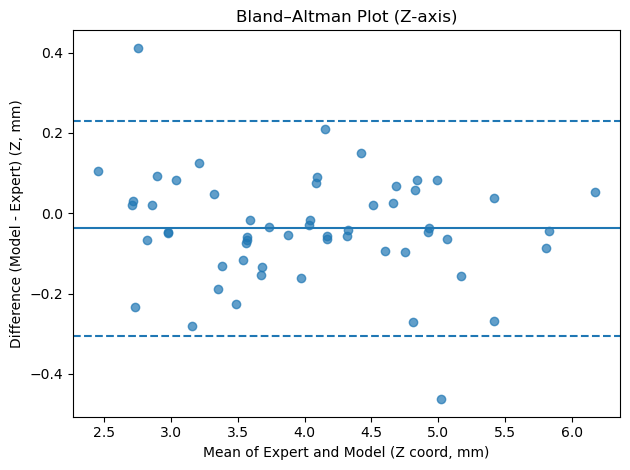

{'mean_diff': np.float32(-0.03770759), 'sd_diff': np.float32(0.13621445), 'loa_lower': np.float32(-0.30468792), 'loa_upper': np.float32(0.22927272)} 



(array([0.34845605, 0.24668089, 0.38217017, 0.35590565, 0.09518916,
        0.22467215, 0.12704802, 0.65193164, 0.18947336, 0.39906278,
        0.39701918, 0.5334676 , 0.42172012, 0.60177815, 0.14249142,
        0.26472068, 0.25934508, 0.21089597, 0.40751463, 0.40889743,
        0.20549798, 0.30861133, 0.31215167, 0.5315017 , 0.56775016,
        0.22213064, 0.22741185, 0.3364167 , 0.14628324, 0.3867059 ,
        0.10546492, 0.44788417, 0.16617641, 0.5722151 , 0.2867468 ,
        0.32347167, 0.06480992, 0.48249617, 0.08910213, 0.32214433,
        0.3334533 , 0.68352836, 0.21488331, 0.2204302 , 0.24793212,
        0.7905208 , 0.1793567 , 0.3185201 , 0.89362663, 1.2643638 ,
        0.7277517 , 0.76102406, 0.29611772, 0.52623856, 0.21110818,
        0.5640241 ], dtype=float32),
 N                56.000000
 mean_TRE_mm       0.375112
 std_TRE_mm        0.227333
 median_TRE_mm     0.322808
 p95_TRE_mm        0.768398
 max_TRE_mm        1.264364
 dtype: float64,
 {'mean': np.float32(0.3751123

In [33]:
evaluate_model_vs_expert(expert_coords_all, model_coords_all, clinical_delta=0.6)